# 01 - Data Preprocessing
## CAVA Group Investment Analysis

This notebook:
1. Loads all raw and processed data
2. Cleans and validates each dataset
3. Engineers features for modeling
4. Merges everything into a master quarterly dataset

**Output:** `data/processed/cava_master_quarterly.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'

print('Libraries loaded.')

Libraries loaded.


---
## Part 1: Load All Data

In [2]:
# ── Load all datasets ──────────────────────────────────────────────────────────
# Raw
price_df      = pd.read_csv(f'{BASE_DIR}/data/raw/cava_stock_price_raw.csv', parse_dates=['date'])
trends_raw    = pd.read_csv(f'{BASE_DIR}/data/raw/cava_google_trends_weekly_raw.csv', parse_dates=['date'])
posts_df      = pd.read_csv(f'{BASE_DIR}/data/raw/cava_reddit_posts_raw.csv', parse_dates=['date'])
comments_df   = pd.read_csv(f'{BASE_DIR}/data/raw/cava_reddit_comments_raw.csv', parse_dates=['date'])
news_df       = pd.read_csv(f'{BASE_DIR}/data/raw/cava_news_raw.csv', parse_dates=['date'])
analyst_df    = pd.read_csv(f'{BASE_DIR}/data/raw/cava_analyst_actions.csv', parse_dates=['date'])

# Processed
q_df          = pd.read_csv(f'{BASE_DIR}/data/processed/cava_quarterly_fundamentals.csv', parse_dates=['period_end'])
trends_monthly= pd.read_csv(f'{BASE_DIR}/data/processed/cava_google_trends_monthly.csv')
reddit_df     = pd.read_csv(f'{BASE_DIR}/data/processed/cava_reddit_combined_sentiment.csv', parse_dates=['date'])

print('All datasets loaded:')
print(f'  Stock price:          {len(price_df):>4} rows')
print(f'  Google Trends weekly: {len(trends_raw):>4} rows')
print(f'  Reddit posts:         {len(posts_df):>4} rows')
print(f'  Reddit comments:      {len(comments_df):>4} rows')
print(f'  News articles:        {len(news_df):>4} rows')
print(f'  Analyst actions:      {len(analyst_df):>4} rows')
print(f'  Quarterly fundamentals:{len(q_df):>3} rows')
print(f'  Google Trends monthly:{len(trends_monthly):>4} rows')
print(f'  Reddit combined:      {len(reddit_df):>4} rows')

All datasets loaded:
  Stock price:           721 rows
  Google Trends weekly:  210 rows
  Reddit posts:          108 rows
  Reddit comments:       707 rows
  News articles:         373 rows
  Analyst actions:       164 rows
  Quarterly fundamentals: 15 rows
  Google Trends monthly:  49 rows
  Reddit combined:        61 rows


---
## Part 2: Clean & Validate Each Dataset

In [3]:
# ── 2A: Quarterly Fundamentals ─────────────────────────────────────────────────
print('=== Quarterly Fundamentals ===')
print(f'Shape: {q_df.shape}')
print(f'Date range: {q_df.period_end.min().date()} to {q_df.period_end.max().date()}')
print(f'Missing values:\n{q_df.isnull().sum()}')

# Sanity check: net_new_openings vs restaurant_count change
q_df_sorted = q_df.sort_values('period_end').reset_index(drop=True)
total_new = q_df_sorted['net_new_openings'].sum()
count_change = q_df_sorted['restaurant_count'].iloc[-1] - q_df_sorted['restaurant_count'].iloc[0]
print(f'\nSanity check:')
print(f'  Sum of net_new_openings: {total_new}')
print(f'  Restaurant count change: {count_change}')
print(f'  Difference: {total_new - count_change} (expected: count before Q2 2022)')

q_df_sorted

=== Quarterly Fundamentals ===
Shape: (15, 12)
Date range: 2022-07-10 to 2025-12-28
Missing values:
quarter                    0
period_end                 0
revenue_m                  0
sssg_pct                   0
auv_in_thousands           0
restaurant_margin_pct      0
restaurant_count           0
net_new_openings           0
digital_revenue_mix_pct    0
adj_ebitda_margin_pct      0
weeks_in_period            0
weekly_revenue_m           0
dtype: int64

Sanity check:
  Sum of net_new_openings: 262
  Restaurant count change: 244
  Difference: 18 (expected: count before Q2 2022)


,quarter,period_end,revenue_m,sssg_pct,auv_in_thousands,restaurant_margin_pct,restaurant_count,net_new_openings,digital_revenue_mix_pct,adj_ebitda_margin_pct,weeks_in_period,weekly_revenue_m
0,Q2 2022,2022-07-10,135.9,13.3,2399,22.1,195,18,33.9,4.3,12,11.325000
1,Q3 2022,2022-10-02,139.3,9.2,2383,21.7,214,19,32.9,3.5,12,11.608333
2,Q4 2022,2023-01-01,123.0,14.8,2398,20.0,237,23,34.5,2.7,12,10.250000
3,Q1 2023,2023-04-16,196.8,28.4,2547,25.4,263,26,36.6,8.2,16,12.300000
4,Q2 2023,2023-07-09,172.9,18.2,2599,26.1,279,16,36.1,12.5,12,14.408333
5,Q3 2023,2023-10-01,175.6,14.1,2640,25.1,290,11,35.5,11.3,12,14.633333
6,Q4 2023,2023-12-31,177.2,11.4,2639,22.4,309,19,35.9,8.9,13,13.630769
7,Q1 2024,2024-04-21,259.0,2.3,2608,25.2,323,14,37.0,12.9,16,16.187500
8,Q2 2024,2024-07-14,233.5,14.4,2689,26.5,341,18,35.8,14.7,12,19.458333
9,Q3 2024,2024-10-06,243.8,18.1,2784,25.6,352,11,35.8,13.7,12,20.316667


In [4]:
# ── 2B: Stock Price ────────────────────────────────────────────────────────────
print('=== Stock Price ===')
print(f'Shape: {price_df.shape}')
print(f'Date range: {price_df.date.min().date()} to {price_df.date.max().date()}')
print(f'Missing values: {price_df.isnull().sum().sum()}')

# Check for gaps (trading days)
price_df = price_df.sort_values('date').reset_index(drop=True)
price_df['return_daily'] = price_df['adj_close_price'].pct_change()

print(f'\nPrice range: ${price_df.adj_close_price.min():.2f} to ${price_df.adj_close_price.max():.2f}')
print(f'Avg daily return: {price_df.return_daily.mean()*100:.3f}%')
price_df.tail()

=== Stock Price ===
Shape: (721, 3)
Date range: 2023-06-15 to 2026-04-30
Missing values: 0

Price range: $29.98 to $150.88
Avg daily return: 0.174%


,date,adj_close_price,volume,return_daily
716,2026-04-24,95.680000,2453300,0.027602
717,2026-04-27,94.230003,1625900,-0.015155
718,2026-04-28,91.040001,3064200,-0.033853
719,2026-04-29,91.110001,1891500,0.000769
720,2026-04-30,93.410004,2425100,0.025244


In [5]:
# ── 2C: Google Trends ──────────────────────────────────────────────────────────
print('=== Google Trends ===')
print(f'Weekly shape: {trends_raw.shape}')
print(f'Monthly shape: {trends_monthly.shape}')
print(f'Columns: {trends_raw.columns.tolist()}')
print(f'Missing values: {trends_raw.isnull().sum().sum()}')

# Normalize trends to 0-1 scale for comparability
trends_raw_clean = trends_raw.copy()
for col in ['cava_restaurant', 'chipotle', 'sweetgreen']:
    if col in trends_raw_clean.columns:
        max_val = trends_raw_clean[col].max()
        print(f'{col} max: {max_val}')
        trends_raw_clean[f'{col}_normalized'] = trends_raw_clean[col] / max_val

print(trends_raw_clean[['cava_restaurant_normalized']].describe())

print(f'\nCAVA trends (raw) range: {trends_raw_clean["cava_restaurant"].min():.1f} to {trends_raw_clean["cava_restaurant"].max():.1f}')
print(f'CAVA trends (normalized) range: {trends_raw_clean["cava_restaurant_normalized"].min():.2f} to {trends_raw_clean["cava_restaurant_normalized"].max():.2f}')
print(f'Chipotle trends (raw) range: {trends_raw_clean["chipotle"].min():.1f} to {trends_raw_clean["chipotle"].max():.1f}')
trends_raw_clean.tail()

=== Google Trends ===
Weekly shape: (210, 4)
Monthly shape: (49, 5)
Columns: ['date', 'cava_restaurant', 'chipotle', 'sweetgreen']
Missing values: 0
cava_restaurant max: 2
chipotle max: 100
sweetgreen max: 6
       cava_restaurant_normalized
count                  210.000000
mean                     0.385714
std                      0.216067
min                      0.000000
25%                      0.500000
50%                      0.500000
75%                      0.500000
max                      1.000000

CAVA trends (raw) range: 0.0 to 2.0
CAVA trends (normalized) range: 0.00 to 1.00
Chipotle trends (raw) range: 52.0 to 100.0


,date,cava_restaurant,chipotle,sweetgreen,cava_restaurant_normalized,chipotle_normalized,sweetgreen_normalized
205,2025-11-30,1,64,4,0.5,0.64,0.666667
206,2025-12-07,1,70,4,0.5,0.70,0.666667
207,2025-12-14,1,71,3,0.5,0.71,0.500000
208,2025-12-21,1,74,2,0.5,0.74,0.333333
209,2025-12-28,1,78,3,0.5,0.78,0.500000


In [6]:
# define the relative change between cava restaurant and chipotle/sweetgreen
# to see if the relative change has been increasing over time

trends_raw_clean['cava_share_of_search'] = (
    trends_raw_clean['cava_restaurant'] / 
    (trends_raw_clean['cava_restaurant'] + trends_raw_clean['chipotle'] + trends_raw_clean['sweetgreen'])
)
print(trends_raw_clean['cava_share_of_search'].describe())

# see if share of search has been increasing
trends_raw_clean['date'] = pd.to_datetime(trends_raw_clean['date'])
trends_raw_clean_sorted = trends_raw_clean.sort_values('date')

trends_raw_clean_sorted['year'] = trends_raw_clean_sorted['date'].dt.year
print(trends_raw_clean_sorted.groupby('year')['cava_share_of_search'].mean())

count    210.000000
mean       0.010719
std        0.006150
min        0.000000
25%        0.010696
50%        0.013423
75%        0.014493
max        0.027778
Name: cava_share_of_search, dtype: float64
year
2021    0.012346
2022    0.003409
2023    0.014307
2024    0.011990
2025    0.013068
Name: cava_share_of_search, dtype: float64


### Google Trends: Signal Assessment

**Finding:** CAVA's share of search interest averages ~1% vs. Chipotle, 
with no clear upward trend (2021: 1.2%, 2023: 1.4% post-IPO, 2025: 1.3%).

**Why this signal is weak:**
1. **Low absolute values (0-2 on Google's 0-100 scale)** — CAVA is still a 
   regional brand with limited national awareness, making weekly data noisy 
   and low-resolution (most weeks are 0 or 1).
2. **No sustained trend** — Share of search spiked around the June 2023 IPO 
   but reverted, suggesting the IPO drove temporary curiosity rather than 
   durable brand momentum.
3. **2022 data anomaly** — Near-zero values in 2022 likely reflect limited 
   geographic coverage rather than true consumer disinterest.

**Investment insight:** CAVA's low search penetration vs. Chipotle indicates 
significant untapped brand awareness nationally. This is a double-edged signal:
bullish (long runway for brand growth) but also a risk (limited pricing power 
outside core markets).

**Modeling decision:** We retain `cava_restaurant` as a feature but expect 
low predictive power. The more informative signal may be the *rate of change* 
in search interest around earnings events, which we examine in the NLP notebook.

In [20]:
# ── 2D: News Sentiment ─────────────────────────────────────────────────────────
print('=== News Sentiment ===')
print(f'Shape: {news_df.shape}')
print(f'Date range: {news_df.date.min()} to {news_df.date.max()}')
print(f'Missing values:\n{news_df.isnull().sum()}')
print(f'\nSentiment distribution:')
print(news_df['combined_sentiment'].describe())

# Check sentiment by source
print(f'\nTop sources:')
print(news_df['source'].value_counts().head(10))

=== News Sentiment ===
Shape: (373, 9)
Date range: 2025-05-07 03:56:57 to 2026-05-01 19:44:12
Missing values:
date                    0
title                   0
summary                 0
source                  0
url                     0
title_sentiment         0
summary_sentiment       0
combined_sentiment      0
quarter               153
dtype: int64

Sentiment distribution:
count    373.000000
mean       0.174049
std        0.264362
min       -0.624700
25%        0.000000
50%        0.136520
75%        0.326040
max        0.845740
Name: combined_sentiment, dtype: float64

Top sources:
source
Yahoo           248
Benzinga         74
SeekingAlpha     23
Fintel           21
Finnhub           4
MarketWatch       2
ChartMill         1
Name: count, dtype: int64


In [9]:
# ── 2E: Reddit Sentiment ───────────────────────────────────────────────────────
print('=== Reddit Combined Sentiment ===')
print(f'Shape: {reddit_df.shape}')
print(f'Date range: {reddit_df.date.min()} to {reddit_df.date.max()}')
print(f'Missing values:\n{reddit_df.isnull().sum()}')
print(f'\nSentiment distribution:')
print(reddit_df['combined_sentiment'].describe())

# Filter to strictly CAVA-related posts
reddit_clean = reddit_df[reddit_df['is_strictly_cava'] == True].copy()
print(f'\nStrictly CAVA posts: {len(reddit_clean)}')

=== Reddit Combined Sentiment ===
Shape: (61, 19)
Date range: 2020-01-02 21:03:28 to 2026-01-09 19:16:41
Missing values:
post_id                        0
date                           0
subreddit                      0
title                          0
selftext                      10
score                          0
num_comments                   0
post_sentiment                 0
post_sentiment_pos             0
post_sentiment_neg             0
url                            0
is_strictly_cava               0
avg_comment_sentiment          3
weighted_comment_sentiment     3
total_comments_scraped         3
avg_comment_score              3
pct_positive_comments          3
pct_negative_comments          3
combined_sentiment             0
dtype: int64

Sentiment distribution:
count    61.000000
mean      0.309300
std       0.282021
min      -0.428624
25%       0.112511
50%       0.336627
75%       0.498841
max       0.915300
Name: combined_sentiment, dtype: float64

Strictly CAVA posts:

In [10]:
# ── 2F: Analyst Actions ────────────────────────────────────────────────────────
print('=== Analyst Actions ===')
print(f'Shape: {analyst_df.shape}')
print(f'Date range: {analyst_df.date.min()} to {analyst_df.date.max()}')
print(f'\nGrade distribution:')
print(analyst_df['tograde'].value_counts())
print(f'\nFirm distribution:')
print(analyst_df['firm'].value_counts().head(10))
analyst_df.tail(10)

=== Analyst Actions ===
Shape: (164, 9)
Date range: 2023-07-09 12:34:06 to 2026-05-01 16:04:58

Grade distribution:
tograde
Buy               43
Neutral           36
Outperform        30
Overweight        24
Equal-Weight      23
Hold               6
Market Perform     2
Name: count, dtype: int64

Firm distribution:
firm
Morgan Stanley    16
Citigroup         14
TD Cowen          14
Barclays          13
Wedbush           12
Stifel            10
UBS               10
JP Morgan          9
Baird              8
Piper Sandler      8
Name: count, dtype: int64


,gradedate,firm,tograde,fromgrade,action,pricetargetaction,currentpricetarget,priorpricetarget,date
154,2026-03-09 12:14:42,Wolfe Research,Outperform,NaN,init,Announces,93.0,0.0,2026-03-09 12:14:42
155,2026-03-26 13:14:10,Guggenheim,Buy,NaN,init,Announces,100.0,0.0,2026-03-26 13:14:10
156,2026-04-02 12:09:42,Mizuho,Neutral,Neutral,main,Raises,80.0,72.0,2026-04-02 12:09:42
157,2026-04-02 12:23:11,TD Cowen,Buy,Buy,main,Raises,100.0,90.0,2026-04-02 12:23:11
158,2026-04-13 17:58:56,Goldman Sachs,Neutral,Neutral,main,Raises,86.0,75.0,2026-04-13 17:58:56
159,2026-04-20 12:15:00,Keybanc,Overweight,Overweight,main,Raises,105.0,95.0,2026-04-20 12:15:00
160,2026-04-20 12:45:40,Benchmark,Buy,Buy,main,Raises,110.0,80.0,2026-04-20 12:45:40
161,2026-04-21 15:16:29,Morgan Stanley,Equal-Weight,Equal-Weight,main,Raises,85.0,83.0,2026-04-21 15:16:29
162,2026-04-24 15:41:55,JP Morgan,Overweight,Overweight,main,Raises,90.0,80.0,2026-04-24 15:41:55
163,2026-05-01 16:04:58,RBC Capital,Outperform,Outperform,main,Raises,100.0,90.0,2026-05-01 16:04:58


#### Visualize the sentiment data distribution

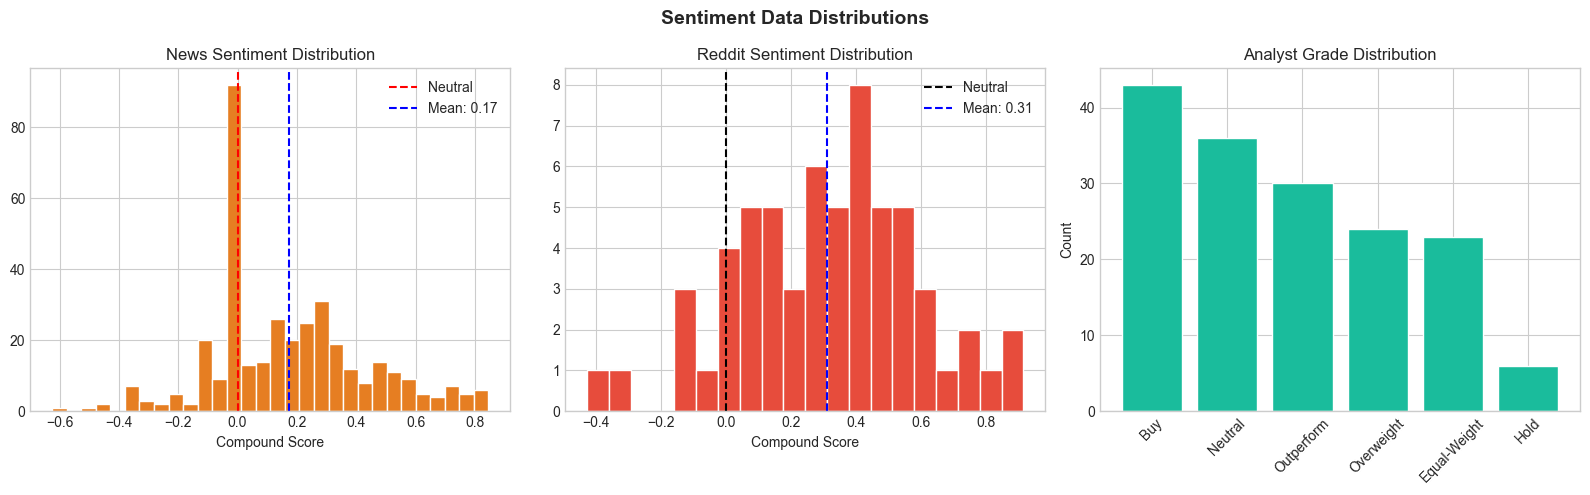

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Data Distributions', fontsize=14, fontweight='bold')

# News sentiment
axes[0].hist(news_df['combined_sentiment'], bins=30, color='#e67e22', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Neutral')
axes[0].axvline(news_df['combined_sentiment'].mean(), color='blue', linestyle='--', 
                label=f'Mean: {news_df["combined_sentiment"].mean():.2f}')
axes[0].set_title('News Sentiment Distribution')
axes[0].set_xlabel('Compound Score')
axes[0].legend()

# Reddit sentiment
axes[1].hist(reddit_clean['combined_sentiment'], bins=20, color='#e74c3c', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', label='Neutral')
axes[1].axvline(reddit_clean['combined_sentiment'].mean(), color='blue', linestyle='--',
                label=f'Mean: {reddit_clean["combined_sentiment"].mean():.2f}')
axes[1].set_title('Reddit Sentiment Distribution')
axes[1].set_xlabel('Compound Score')
axes[1].legend()

# Analyst grades
analyst_counts = analyst_df['tograde'].value_counts()
axes[2].bar(analyst_counts.index[:6], analyst_counts.values[:6], 
            color='#1abc9c', edgecolor='white')
axes[2].set_title('Analyst Grade Distribution')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/sentiment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3: Feature Engineering

In [25]:
# ── 3A: Stock Price → Quarterly Features ──────────────────────────────────────
# Create quarter boundaries
q_df_sorted = q_df.sort_values('period_end').reset_index(drop=True)
q_df_sorted['period_start'] = q_df_sorted['period_end'].shift(1) + pd.Timedelta(days=1)
q_df_sorted.loc[0, 'period_start'] = pd.Timestamp('2022-04-01')  # approximate start

# Calculate return_daily BEFORE assigning quarters
price_df = price_df.sort_values('date').reset_index(drop=True)
price_df['return_daily'] = price_df['adj_close_price'].pct_change()

# Assign each price row to a quarter
price_df['quarter'] = None
for _, q_row in q_df_sorted.iterrows():
    mask = (price_df['date'] >= q_row['period_start']) & \
           (price_df['date'] <= q_row['period_end'])
    price_df.loc[mask, 'quarter'] = q_row['quarter']

print(f'Price rows assigned to quarters: {price_df["quarter"].notna().sum()} / {len(price_df)}')

# Aggregate to quarterly
price_quarterly = price_df.dropna(subset=['quarter']).groupby('quarter').agg(
    avg_price=('adj_close_price', 'mean'),
    end_price=('adj_close_price', 'last'),
    start_price=('adj_close_price', 'first'),
    price_volatility=('return_daily', 'std'),
    avg_volume=('volume', 'mean')
).reset_index()

price_quarterly['quarterly_return'] = (
    (price_quarterly['end_price'] - price_quarterly['start_price']) /
    price_quarterly['start_price'] * 100
)

# Sort by period_end (not alphabetically)
quarter_order = q_df_sorted[['quarter', 'period_end']].copy()
price_quarterly = price_quarterly.merge(quarter_order, on='quarter', how='left')
price_quarterly = price_quarterly.sort_values('period_end').reset_index(drop=True)

print(f'Price quarterly features: {len(price_quarterly)} quarters')
price_quarterly

Price rows assigned to quarters: 636 / 721
Price quarterly features: 11 quarters


,quarter,avg_price,end_price,start_price,price_volatility,avg_volume,quarterly_return,period_end
0,Q2 2023,40.612000,39.619999,43.779999,0.054983,2.984773e+06,-9.502056,2023-07-09
1,Q3 2023,43.951186,30.629999,44.000000,0.045105,1.789249e+06,-30.386366,2023-10-01
2,Q4 2023,34.865079,42.980000,31.000000,0.039850,1.918273e+06,38.645160,2023-12-31
3,Q1 2024,55.595526,59.669998,40.869999,0.032344,2.213350e+06,45.999510,2024-04-21
4,Q2 2024,82.939123,84.250000,59.610001,0.033885,3.207665e+06,41.335345,2024-07-14
5,Q3 2024,104.783051,126.599998,86.629997,0.037037,3.153066e+06,46.138754,2024-10-06
6,Q4 2024,134.706725,114.370003,126.000000,0.027078,2.697738e+06,-9.230157,2024-12-29
7,Q1 2025,104.585333,86.000000,111.519997,0.044811,3.328289e+06,-22.883785,2025-04-20
8,Q2 2025,85.429474,92.050003,80.370003,0.029275,3.726170e+06,14.532786,2025-07-13
9,Q3 2025,73.570000,63.529999,89.860001,0.032152,4.675800e+06,-29.301137,2025-10-05


In [26]:
# ── 3B: Google Trends → Quarterly Features ────────────────────────────────────
trends_raw_clean['date'] = pd.to_datetime(trends_raw_clean['date'])

# Assign quarter
trends_raw_clean['quarter'] = None
for _, q_row in q_df_sorted.iterrows():
    mask = (trends_raw_clean['date'] >= q_row['period_start']) & \
           (trends_raw_clean['date'] <= q_row['period_end'])
    trends_raw_clean.loc[mask, 'quarter'] = q_row['quarter']

# Get CAVA trends column name
cava_col = [c for c in trends_raw_clean.columns if 'cava' in c.lower() and 'normalized' not in c][0]
print(f'Using trends column: {cava_col}')

trends_quarterly = trends_raw_clean.dropna(subset=['quarter']).groupby('quarter').agg(
    avg_search_interest=(cava_col, 'mean'),
    max_search_interest=(cava_col, 'max'),
    search_interest_std=(cava_col, 'std')
).reset_index()

# Fix QoQ: replace inf with NaN (caused by division by zero when previous quarter = 0)
trends_quarterly['search_interest_qoq'] = trends_quarterly['avg_search_interest'].pct_change() * 100
trends_quarterly['search_interest_qoq'] = trends_quarterly['search_interest_qoq'].replace(
    [np.inf, -np.inf], np.nan
)

# Sort by period_end
trends_quarterly = trends_quarterly.merge(
    q_df_sorted[['quarter', 'period_end']], on='quarter', how='left'
)
trends_quarterly = trends_quarterly.sort_values('period_end').reset_index(drop=True)

print(f'Trends quarterly features: {len(trends_quarterly)} quarters')
trends_quarterly

Using trends column: cava_restaurant
Trends quarterly features: 15 quarters


,quarter,avg_search_interest,max_search_interest,search_interest_std,search_interest_qoq,period_end
0,Q2 2022,0.066667,1,0.258199,-93.333333,2022-07-10
1,Q3 2022,0.000000,0,0.000000,-100.000000,2022-10-02
2,Q4 2022,0.846154,1,0.375534,1.538462,2023-01-01
3,Q1 2023,1.000000,1,0.000000,NaN,2023-04-16
4,Q2 2023,1.083333,2,0.288675,1525.000000,2023-07-09
5,Q3 2023,0.916667,1,0.288675,NaN,2023-10-01
6,Q4 2023,1.000000,1,0.000000,18.181818,2023-12-31
7,Q1 2024,0.687500,1,0.478714,-31.250000,2024-04-21
8,Q2 2024,1.000000,1,0.000000,-7.692308,2024-07-14
9,Q3 2024,1.000000,1,0.000000,9.090909,2024-10-06


In [27]:
# ── 3C: News Sentiment → Quarterly Features ───────────────────────────────────
news_df['date'] = pd.to_datetime(news_df['date'])

# Assign quarter
news_df['quarter'] = None
for _, q_row in q_df_sorted.iterrows():
    mask = (news_df['date'] >= q_row['period_start']) & \
           (news_df['date'] <= q_row['period_end'])
    news_df.loc[mask, 'quarter'] = q_row['quarter']

news_quarterly = news_df.dropna(subset=['quarter']).groupby('quarter').agg(
    avg_news_sentiment=('combined_sentiment', 'mean'),
    news_article_count=('title', 'count'),
    pct_positive_news=('combined_sentiment', lambda x: (x > 0.05).sum() / len(x)),
    pct_negative_news=('combined_sentiment', lambda x: (x < -0.05).sum() / len(x))
).reset_index()

print(f'News quarterly features: {len(news_quarterly)} quarters')
news_quarterly

News quarterly features: 3 quarters


,quarter,avg_news_sentiment,news_article_count,pct_positive_news,pct_negative_news
0,Q2 2025,0.283500,57,0.789474,0.000000
1,Q3 2025,0.166805,20,0.550000,0.100000
2,Q4 2025,0.143647,143,0.531469,0.230769


#### Reddit Data: Outlier Detection & Treatment

**Finding:** Q3 2025 shows an unusually high average upvote count (657) compared to 
other quarters (~30-190 range), suggesting a viral post is skewing the distribution.

**Investigation:** Filtering Reddit posts from Q3 2025 (July 14 – October 5, 2025) 
and sorting by upvotes reveals the following top posts:

| Date | Title | Upvotes | Comments |
|------|-------|---------|----------|
| Aug 12, 2025 | "Cava down -20% after hours" | 2,168 | 528 |
| Aug 14, 2025 | "Is this CAVA bull ok?" | 1,524 | 202 |
| Aug 12, 2025 | "Cava stock plummets after company lowers forecast..." | 433 | 118 |

**Root Cause:** These viral posts directly correspond to CAVA's Q2 2025 earnings 
release on August 12, 2025, when the stock dropped ~20% after hours — its worst 
single-day decline on record. The selloff was driven by:
- Same-restaurant sales growth of only 2.1%, significantly missing the 6-6.5% consensus
- Management lowering full-year SSSG guidance from 6-8% to 4-6%
- CEO described consumers as "navigating a fog"

This is entirely consistent with our fundamental data: Q2 2025 SSSG = 2.1%, 
Q3 2025 SSSG = 1.9% — confirming a structural deceleration in comp sales growth.

**Treatment:** These posts represent real market events, not data errors — they 
should be retained. However, to avoid the mean upvote metric being dominated by 
a single event, we replace `avg_reddit_upvotes` with `median_reddit_upvotes`, 
which is more robust to outliers while preserving the directional signal.

In [34]:
# ── 3D: Reddit Sentiment → Quarterly Features ─────────────────────────────────
reddit_clean['date'] = pd.to_datetime(reddit_clean['date'])

# Assign quarter
reddit_clean['quarter'] = None
for _, q_row in q_df_sorted.iterrows():
    mask = (reddit_clean['date'] >= q_row['period_start']) & \
           (reddit_clean['date'] <= q_row['period_end'])
    reddit_clean.loc[mask, 'quarter'] = q_row['quarter']

reddit_quarterly = reddit_clean.dropna(subset=['quarter']).groupby('quarter').agg(
    avg_reddit_sentiment=('combined_sentiment', 'mean'),
    reddit_post_count=('post_id', 'count'),
    median_reddit_upvotes=('score', 'median'),  # median: robust to viral post outliers
    max_reddit_upvotes=('score', 'max')          # max: flag quarters with major events
).reset_index()

# Sort by period_end
reddit_quarterly = reddit_quarterly.merge(
    q_df_sorted[['quarter', 'period_end']], on='quarter', how='left'
)
reddit_quarterly = reddit_quarterly.sort_values('period_end').reset_index(drop=True)

print(f'Reddit quarterly features: {len(reddit_quarterly)} quarters')
print('Note: using median upvotes to reduce influence of viral earnings-event posts')
reddit_quarterly

Reddit quarterly features: 12 quarters
Note: using median upvotes to reduce influence of viral earnings-event posts


,quarter,avg_reddit_sentiment,reddit_post_count,median_reddit_upvotes,max_reddit_upvotes,period_end
0,Q3 2022,-0.077200,1,0.0,0,2022-10-02
1,Q2 2023,0.289909,3,4.0,472,2023-07-09
2,Q3 2023,-0.080869,2,5.5,7,2023-10-01
3,Q4 2023,0.331392,7,27.0,289,2023-12-31
4,Q1 2024,0.518412,4,142.5,480,2024-04-21
5,Q2 2024,0.124943,9,42.0,842,2024-07-14
6,Q3 2024,0.306811,12,15.0,124,2024-10-06
7,Q4 2024,0.394806,5,1.0,83,2024-12-29
8,Q1 2025,0.529506,3,6.0,32,2025-04-20
9,Q2 2025,0.591730,5,13.0,101,2025-07-13


In [33]:
# Find Q3 2025 posts，ranked by number of upvotes
q3_2025_start = pd.Timestamp('2025-07-14')
q3_2025_end = pd.Timestamp('2025-10-05')

viral = reddit_clean[
    (reddit_clean['date'] >= q3_2025_start) & 
    (reddit_clean['date'] <= q3_2025_end)
].sort_values('score', ascending=False)

print(viral[['date', 'title', 'score', 'num_comments', 'combined_sentiment']].to_string())

                  date                                                                                       title  score  num_comments  combined_sentiment
11 2025-08-12 20:21:04                                                                  Cava down -20% after hours   2168           528            0.438898
9  2025-08-14 03:50:01                                                                       Is this CAVA bull ok?   1524           202            0.039850
12 2025-08-12 20:20:51  Cava stock plummets after company lowers forecast on disappointing same-store sales growth    433           118            0.055465
10 2025-08-12 23:09:01                                                                         Going all into CAVA    242           206            0.047522
13 2025-08-12 16:25:13                                                                           CAVA will melt up    154           105            0.220796
1  2025-10-01 01:00:45                                          

In [35]:
# ── 3E: Analyst Actions → Quarterly Features ──────────────────────────────────
analyst_df['date'] = pd.to_datetime(analyst_df['date'])

# Map grades to numeric scores
# Positive: Buy, Outperform, Overweight, Strong Buy
# Neutral: Hold, Neutral, Equal-Weight, Market Perform
# Negative: Sell, Underperform, Underweight
def grade_to_score(grade):
    grade = str(grade).lower()
    if any(x in grade for x in ['buy', 'outperform', 'overweight', 'positive']):
        return 1
    elif any(x in grade for x in ['sell', 'underperform', 'underweight', 'negative']):
        return -1
    else:
        return 0

analyst_df['grade_score'] = analyst_df['tograde'].apply(grade_to_score)

# Assign quarter
analyst_df['quarter'] = None
for _, q_row in q_df_sorted.iterrows():
    mask = (analyst_df['date'] >= q_row['period_start']) & \
           (analyst_df['date'] <= q_row['period_end'])
    analyst_df.loc[mask, 'quarter'] = q_row['quarter']

analyst_quarterly = analyst_df.dropna(subset=['quarter']).groupby('quarter').agg(
    avg_analyst_score=('grade_score', 'mean'),
    analyst_action_count=('firm', 'count'),
    pct_bullish=('grade_score', lambda x: (x == 1).sum() / len(x)),
    pct_bearish=('grade_score', lambda x: (x == -1).sum() / len(x))
).reset_index()

analyst_quarterly = analyst_quarterly.merge(
    q_df_sorted[['quarter', 'period_end']], on='quarter', how='left'
)
analyst_quarterly = analyst_quarterly.sort_values('period_end').reset_index(drop=True)

print(f'Analyst quarterly features: {len(analyst_quarterly)} quarters')
analyst_quarterly

Analyst quarterly features: 10 quarters


,quarter,avg_analyst_score,analyst_action_count,pct_bullish,pct_bearish,period_end
0,Q3 2023,0.615385,13,0.615385,0.0,2023-10-01
1,Q4 2023,0.571429,7,0.571429,0.0,2023-12-31
2,Q1 2024,0.823529,17,0.823529,0.0,2024-04-21
3,Q2 2024,0.727273,11,0.727273,0.0,2024-07-14
4,Q3 2024,0.666667,18,0.666667,0.0,2024-10-06
5,Q4 2024,0.307692,13,0.307692,0.0,2024-12-29
6,Q1 2025,0.545455,11,0.545455,0.0,2025-04-20
7,Q2 2025,0.636364,11,0.636364,0.0,2025-07-13
8,Q3 2025,0.363636,11,0.363636,0.0,2025-10-05
9,Q4 2025,0.529412,17,0.529412,0.0,2025-12-28


In [31]:
# double check to if there is any bearish grades
print(analyst_df['tograde'].unique())
print(analyst_df[analyst_df['grade_score'] == -1]['tograde'].value_counts())
# no sell / underperform grades, so normal to see all zero bearish scores

<StringArray>
[    'Outperform',        'Neutral',     'Overweight',            'Buy',
   'Equal-Weight',           'Hold', 'Market Perform']
Length: 7, dtype: str
Series([], Name: count, dtype: int64)


---
## Part 4: Merge into Master Quarterly Dataset

In [36]:
# ── Merge all quarterly features ──────────────────────────────────────────────
master = q_df_sorted.copy()

# Drop period_end from feature dfs before merging to avoid duplicates
merge_dfs = [
    (price_quarterly.drop(columns=['period_end'], errors='ignore'),    'quarter', 'Stock Price'),
    (trends_quarterly.drop(columns=['period_end'], errors='ignore'),   'quarter', 'Google Trends'),
    (news_quarterly.drop(columns=['period_end'], errors='ignore'),     'quarter', 'News Sentiment'),
    (reddit_quarterly.drop(columns=['period_end'], errors='ignore'),   'quarter', 'Reddit Sentiment'),
    (analyst_quarterly.drop(columns=['period_end'], errors='ignore'),  'quarter', 'Analyst Actions'),
]

for df, key, name in merge_dfs:
    before = len(master)
    master = master.merge(df, on=key, how='left')
    print(f'Merged {name}: {before} → {len(master)} rows')

# ── Event flags ────────────────────────────────────────────────────────────────
# IPO quarter
master['ipo_quarter'] = (master['quarter'] == 'Q2 2023').astype(int)

# SSSG beat quarters (actual vs consensus significantly positive)
# Q3 2024: 18.1% vs ~9% expected → massive beat
# Q4 2024: 21.2% vs ~15% expected → beat
master['sssg_beat'] = master['quarter'].isin(['Q3 2024', 'Q4 2024']).astype(int)

# SSSG miss quarters
# Q1 2024: 2.3% vs ~10% expected → massive miss
# Q2 2025: 2.1% vs 6-6.5% expected → miss, stock -22%
# Q3 2025: 1.9% vs 2.8% expected → miss, stock -10%
# Q4 2025: 0.5% vs ~2% expected → miss
master['sssg_miss'] = master['quarter'].isin(
    ['Q1 2024', 'Q2 2025', 'Q3 2025', 'Q4 2025']
).astype(int)

# Guidance cut quarters
# Q2 2025: cut FY guidance from 6-8% to 4-6%
# Q3 2025: cut again from 4-6% to 3-4%
master['guidance_cut'] = master['quarter'].isin(['Q2 2025', 'Q3 2025']).astype(int)

# All-time high quarter (Nov 2024, so Q4 2024)
master['ath_quarter'] = (master['quarter'] == 'Q4 2024').astype(int)

print(f'\nMaster dataset shape: {master.shape}')
print(f'Columns: {master.columns.tolist()}')
print('\nEvent flags:')
print(master[['quarter', 'ipo_quarter', 'sssg_beat', 'sssg_miss',
              'guidance_cut', 'ath_quarter']].to_string())

Merged Stock Price: 15 → 15 rows
Merged Google Trends: 15 → 15 rows
Merged News Sentiment: 15 → 15 rows
Merged Reddit Sentiment: 15 → 15 rows
Merged Analyst Actions: 15 → 15 rows

Master dataset shape: (15, 40)
Columns: ['quarter', 'period_end', 'revenue_m', 'sssg_pct', 'auv_in_thousands', 'restaurant_margin_pct', 'restaurant_count', 'net_new_openings', 'digital_revenue_mix_pct', 'adj_ebitda_margin_pct', 'weeks_in_period', 'weekly_revenue_m', 'period_start', 'avg_price', 'end_price', 'start_price', 'price_volatility', 'avg_volume', 'quarterly_return', 'avg_search_interest', 'max_search_interest', 'search_interest_std', 'search_interest_qoq', 'avg_news_sentiment', 'news_article_count', 'pct_positive_news', 'pct_negative_news', 'avg_reddit_sentiment', 'reddit_post_count', 'median_reddit_upvotes', 'max_reddit_upvotes', 'avg_analyst_score', 'analyst_action_count', 'pct_bullish', 'pct_bearish', 'ipo_quarter', 'sssg_beat', 'sssg_miss', 'guidance_cut', 'ath_quarter']

Event flags:
    quarter

In [44]:
master = master.drop(columns=['max_reddit_upvotes','avg_reddit_upvotes' 'pct_bearish'], errors='ignore')

In [45]:
# ── Check missing values in master ────────────────────────────────────────────
print('Missing values in master dataset:')
missing = master.isnull().sum()
missing = missing[missing > 0]
print(missing)

# Note: missing values are expected for:
# - price features (CAVA IPO June 2023, so 2022 quarters will be NaN)
# - news/reddit (sparse data, not all quarters have coverage)
# - search_interest_qoq (first quarter will be NaN by definition)

Missing values in master dataset:
avg_price                 4
end_price                 4
start_price               4
price_volatility          4
avg_volume                4
quarterly_return          4
avg_news_sentiment       12
pct_positive_news        12
pct_negative_news        12
avg_reddit_sentiment      3
median_reddit_upvotes     3
avg_analyst_score         5
pct_bullish               5
dtype: int64


In [46]:
# See which quarters have missing values for key features
cols_with_missing = ['avg_price', 'avg_news_sentiment', 'avg_reddit_sentiment', 
                     'avg_analyst_score', 'search_interest_qoq']

for col in cols_with_missing:
    missing_rows = master[master[col].isna()][['quarter', 'period_end', col]]
    print(f'\n{col} — {missing_rows.shape[0]} missing:')
    print(missing_rows.to_string())


avg_price — 4 missing:
   quarter period_end  avg_price
0  Q2 2022 2022-07-10        NaN
1  Q3 2022 2022-10-02        NaN
2  Q4 2022 2023-01-01        NaN
3  Q1 2023 2023-04-16        NaN

avg_news_sentiment — 12 missing:
    quarter period_end  avg_news_sentiment
0   Q2 2022 2022-07-10                 NaN
1   Q3 2022 2022-10-02                 NaN
2   Q4 2022 2023-01-01                 NaN
3   Q1 2023 2023-04-16                 NaN
4   Q2 2023 2023-07-09                 NaN
5   Q3 2023 2023-10-01                 NaN
6   Q4 2023 2023-12-31                 NaN
7   Q1 2024 2024-04-21                 NaN
8   Q2 2024 2024-07-14                 NaN
9   Q3 2024 2024-10-06                 NaN
10  Q4 2024 2024-12-29                 NaN
11  Q1 2025 2025-04-20                 NaN

avg_reddit_sentiment — 3 missing:
   quarter period_end  avg_reddit_sentiment
0  Q2 2022 2022-07-10                   NaN
2  Q4 2022 2023-01-01                   NaN
3  Q1 2023 2023-04-16                   NaN

avg_an

### Missing Value Treatment

| Column | Missing Quarters | Reason | Treatment |
|--------|-----------------|--------|-----------|
| avg_price, quarterly_return, etc. | Q2-Q4 2022, Q1 2023 | Pre-IPO (CAVA listed June 2023) | Keep NaN, exclude from price-based models |
| avg_analyst_score, pct_bullish | Q2-Q4 2022, Q1-Q2 2023 | No analyst coverage pre-IPO | Keep NaN |
| avg_news_sentiment | Q2 2022 – Q1 2025 | Finnhub free tier limited to 2025+ | Keep NaN, add has_news_data flag |
| avg_reddit_sentiment | 3 quarters | Low post volume / search precision | Keep NaN, add has_reddit_data flag |
| search_interest_qoq | Q2 2022 | First row, no prior period | Fill with 0 |
| news/reddit/analyst count | Various | No activity in period | Fill with 0 |

In [40]:
# Fill 0 for count categories
master['news_article_count'] = master['news_article_count'].fillna(0)
master['reddit_post_count'] = master['reddit_post_count'].fillna(0)
master['analyst_action_count'] = master['analyst_action_count'].fillna(0)
master['search_interest_qoq'] = master['search_interest_qoq'].fillna(0)

# add data availability flags
master['has_news_data'] = master['avg_news_sentiment'].notna().astype(int)
master['has_analyst_data'] = master['avg_analyst_score'].notna().astype(int)

print('Missing values after treatment:')
print(master.isnull().sum()[master.isnull().sum() > 0])
print(f'\nFinal shape: {master.shape}')

Missing values after treatment:
avg_price                 4
end_price                 4
start_price               4
price_volatility          4
avg_volume                4
quarterly_return          4
avg_news_sentiment       12
pct_positive_news        12
pct_negative_news        12
avg_reddit_sentiment      3
median_reddit_upvotes     3
max_reddit_upvotes        3
avg_analyst_score         5
pct_bullish               5
pct_bearish               5
dtype: int64

Final shape: (15, 43)


In [48]:
# ── Add lag features for modeling ─────────────────────────────────────────────
master = master.sort_values('period_end').reset_index(drop=True)

# Lag SSSG (target variable for modeling)
master['sssg_pct_lag1'] = master['sssg_pct'].shift(1)
master['sssg_pct_lag2'] = master['sssg_pct'].shift(2)

# Lead SSSG (what we want to predict)
master['sssg_pct_next'] = master['sssg_pct'].shift(-1)

# Rolling average SSSG (trend)
master['sssg_rolling_3q'] = master['sssg_pct'].rolling(3).mean()

# QoQ change in key metrics
auv_col = [c for c in master.columns if 'auv' in c.lower()][0]
master['auv_qoq'] = master[auv_col].pct_change() * 100
master['margin_qoq'] = master['restaurant_margin_pct'].diff()
master['digital_mix_qoq'] = master['digital_revenue_mix_pct'].diff()

print('Lag features added:')
print(master[['quarter', 'sssg_pct', 'sssg_pct_lag1', 'sssg_pct_next']].to_string())

Lag features added:
    quarter  sssg_pct  sssg_pct_lag1  sssg_pct_next
0   Q2 2022      13.3            NaN            9.2
1   Q3 2022       9.2           13.3           14.8
2   Q4 2022      14.8            9.2           28.4
3   Q1 2023      28.4           14.8           18.2
4   Q2 2023      18.2           28.4           14.1
5   Q3 2023      14.1           18.2           11.4
6   Q4 2023      11.4           14.1            2.3
7   Q1 2024       2.3           11.4           14.4
8   Q2 2024      14.4            2.3           18.1
9   Q3 2024      18.1           14.4           21.2
10  Q4 2024      21.2           18.1           10.8
11  Q1 2025      10.8           21.2            2.1
12  Q2 2025       2.1           10.8            1.9
13  Q3 2025       1.9            2.1            0.5
14  Q4 2025       0.5            1.9            NaN


---
## Part 5: Validation Plots

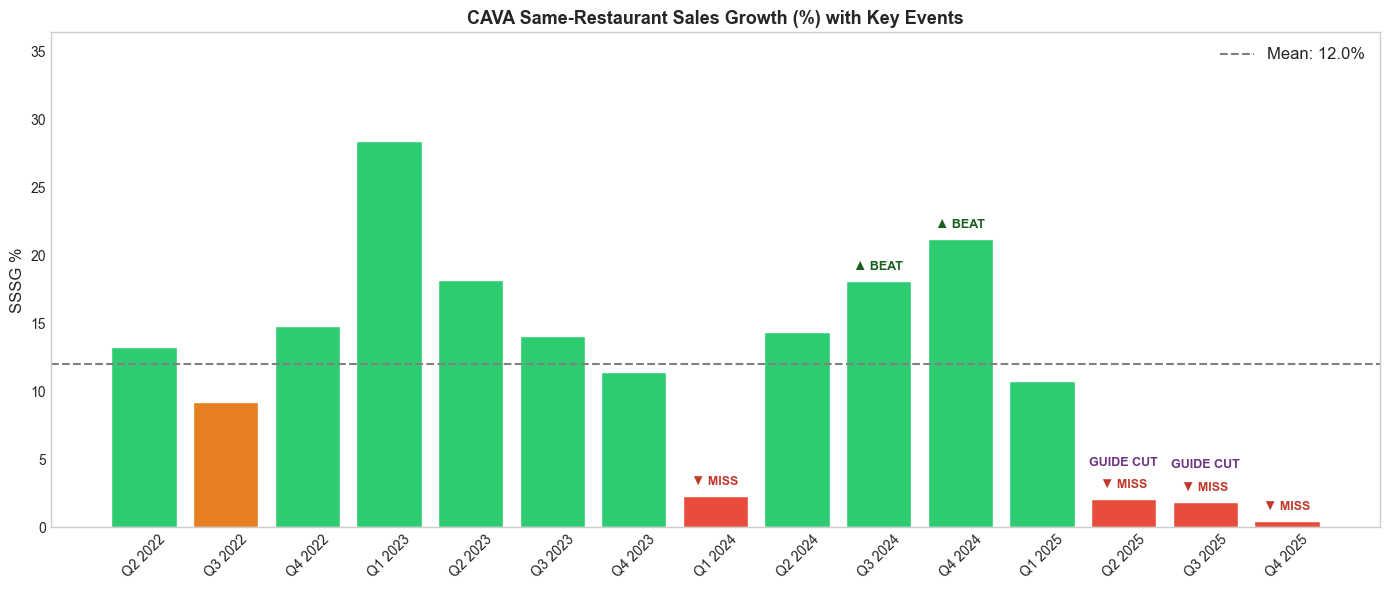

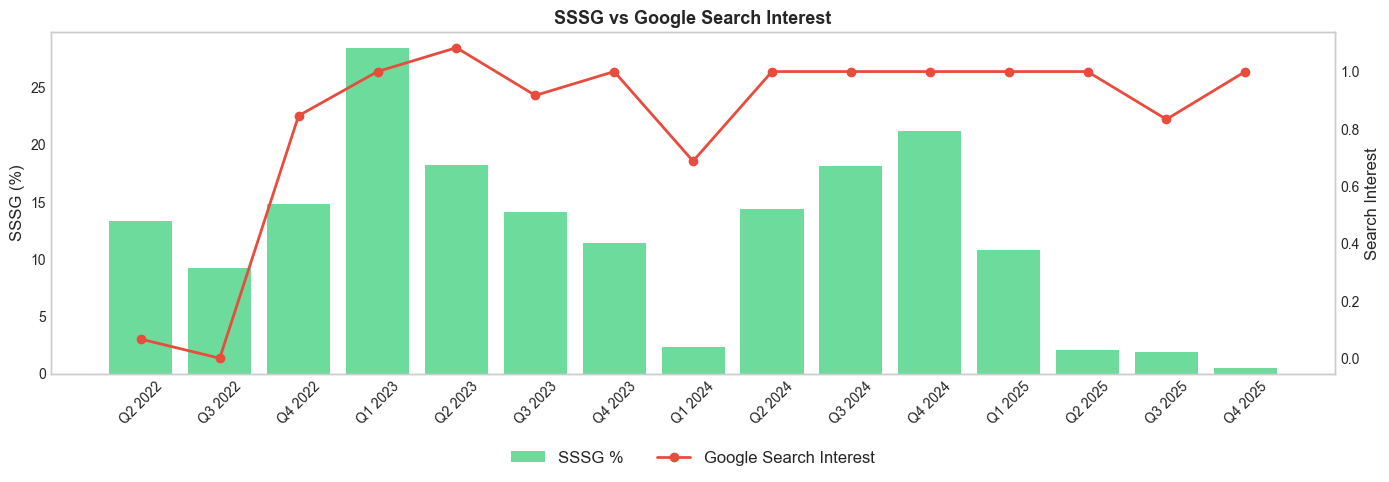

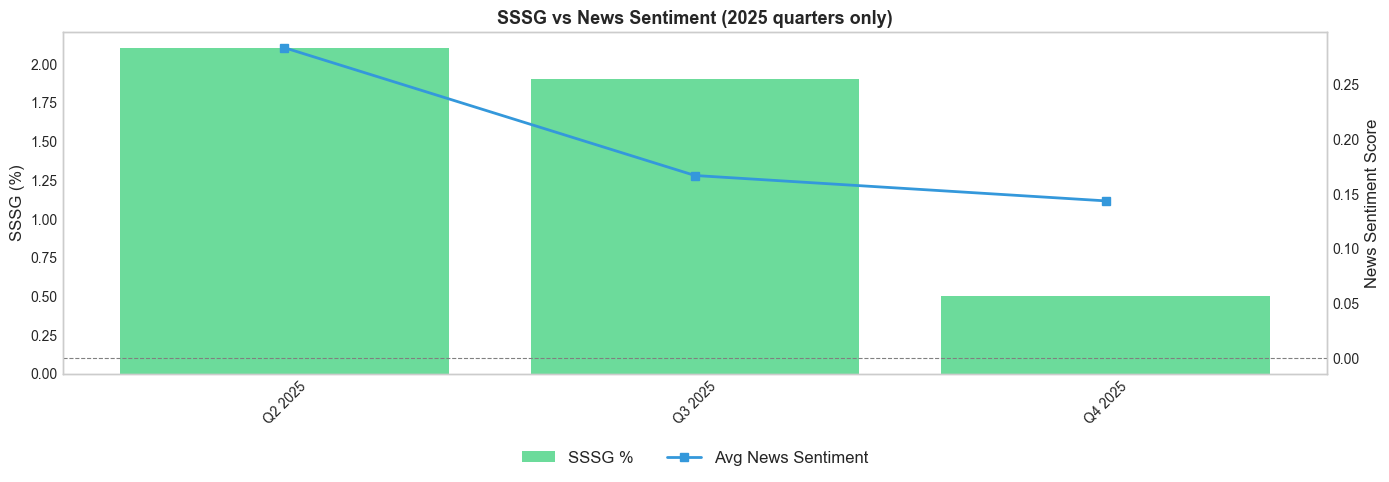

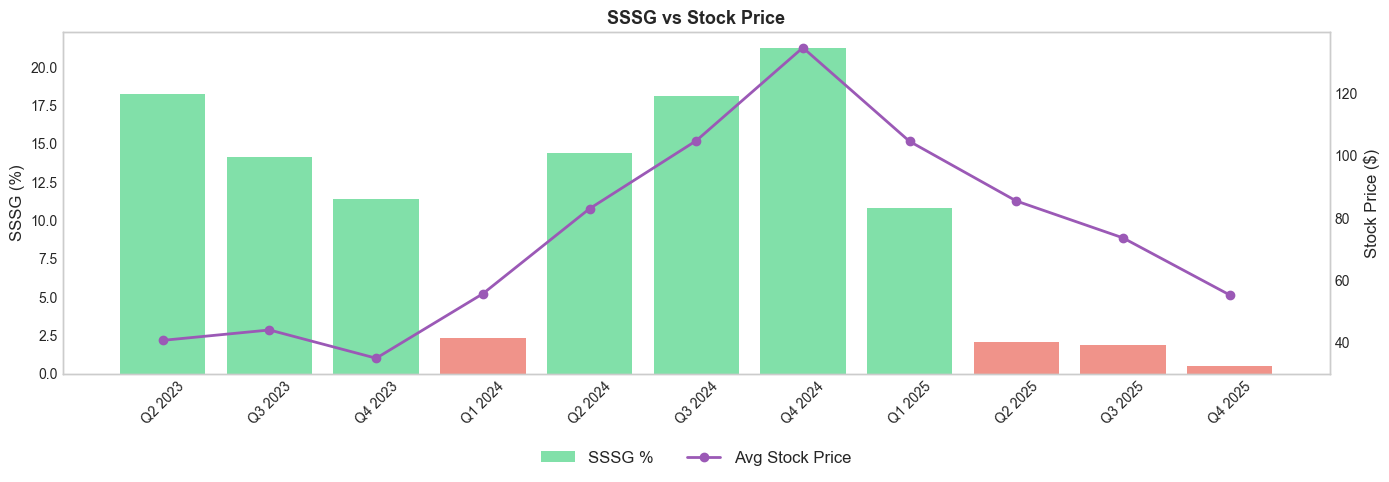

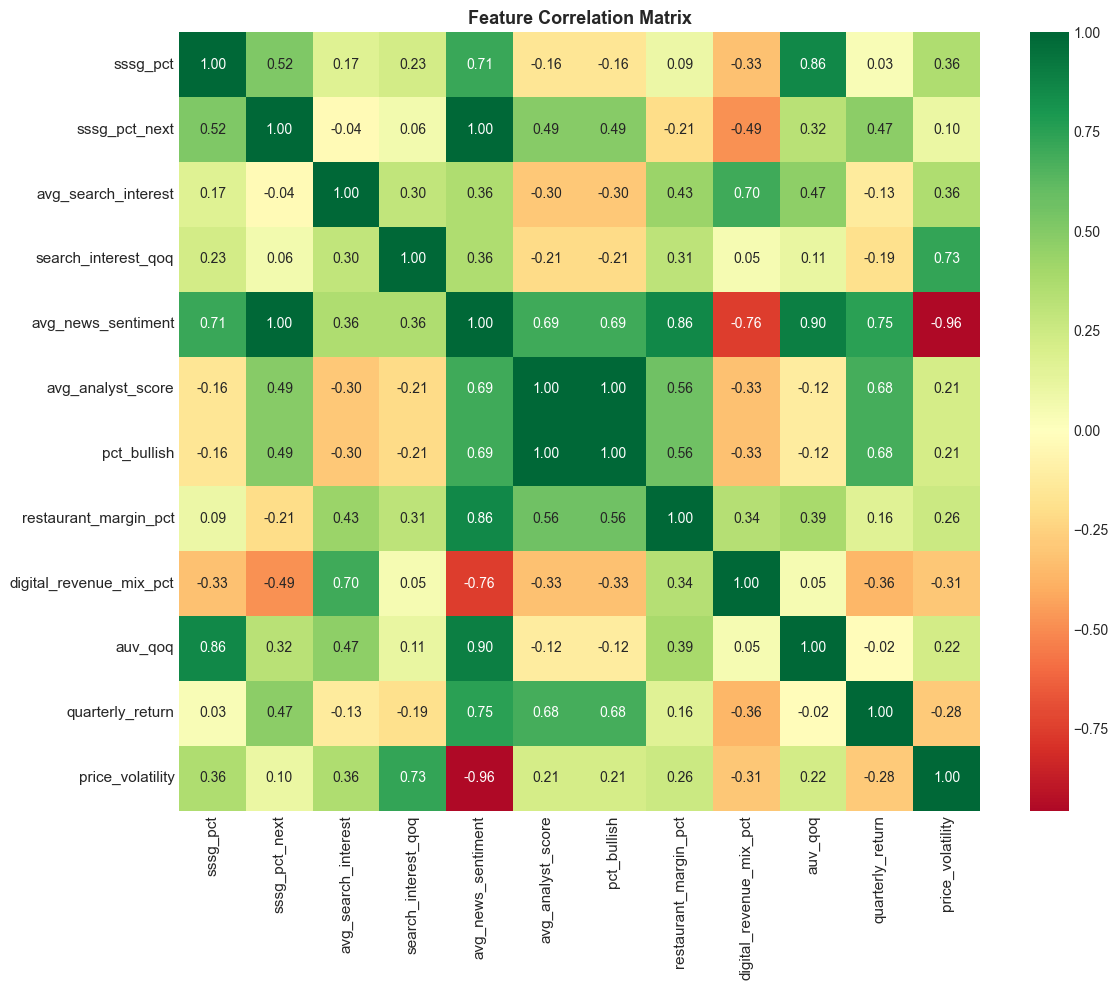

All validation plots saved to outputs/figures/


In [73]:
# ── Global style settings ──────────────────────────────────────────────────────
plt.rcParams.update({
    'axes.grid': False,
    'legend.fontsize': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

# ── Plot 1: SSSG with Key Events ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2ecc71' if v > 10 else '#e67e22' if v > 5 else '#e74c3c' 
          for v in master['sssg_pct']]
ax.bar(master['quarter'], master['sssg_pct'], color=colors, edgecolor='white')
ax.axhline(master['sssg_pct'].mean(), color='gray', linestyle='--',
           label=f'Mean: {master["sssg_pct"].mean():.1f}%')

for _, row in master.iterrows():
    annotations = []
    if row['sssg_miss'] == 1:
        annotations.append(('▼ MISS', '#c0392b'))
    if row['sssg_beat'] == 1:
        annotations.append(('▲ BEAT', '#1a5e20'))
    if row['guidance_cut'] == 1:
        annotations.append(('GUIDE CUT', '#6c3483'))
    for i, (text, color) in enumerate(annotations):
        ax.annotate(text, xy=(row['quarter'], row['sssg_pct']),
                   xytext=(0, 8 + i * 16), textcoords='offset points',
                   ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_title('CAVA Same-Restaurant Sales Growth (%) with Key Events', fontweight='bold')
ax.set_ylabel('SSSG %')
ax.set_ylim(0, master['sssg_pct'].max() + 8)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/sssg_with_events.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: SSSG vs Google Trends ─────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(master['quarter'], master['sssg_pct'],
        color=['#2ecc71' if v > 0 else '#e74c3c' for v in master['sssg_pct']],
        alpha=0.7, label='SSSG %')
ax1.set_ylabel('SSSG (%)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(master['quarter'], master['avg_search_interest'],
         color='#e74c3c', linewidth=2, marker='o', label='Google Search Interest')
ax2.set_ylabel('Search Interest')

ax1.set_title('SSSG vs Google Search Interest', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, fontsize=12)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/sssg_vs_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: SSSG vs News Sentiment ────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

plot_df = master.dropna(subset=['avg_news_sentiment'])
ax1.bar(plot_df['quarter'], plot_df['sssg_pct'],
        color=['#2ecc71' if v > 0 else '#e74c3c' for v in plot_df['sssg_pct']],
        alpha=0.7, label='SSSG %')
ax1.set_ylabel('SSSG (%)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(plot_df['quarter'], plot_df['avg_news_sentiment'],
         color='#3498db', linewidth=2, marker='s', label='Avg News Sentiment')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_ylabel('News Sentiment Score')

ax1.set_title('SSSG vs News Sentiment (2025 quarters only)', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/sssg_vs_news_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: SSSG vs Stock Price ───────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

plot_df = master.dropna(subset=['avg_price'])
ax1.bar(plot_df['quarter'], plot_df['sssg_pct'],
        color=['#2ecc71' if v > 10 else '#e74c3c' for v in plot_df['sssg_pct']],
        alpha=0.6, label='SSSG %')
ax1.set_ylabel('SSSG (%)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(plot_df['quarter'], plot_df['avg_price'],
         color='#9b59b6', linewidth=2, marker='o', label='Avg Stock Price')
ax2.set_ylabel('Stock Price ($)')

ax1.set_title('SSSG vs Stock Price', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/sssg_vs_stock_price.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 5: Correlation Heatmap ────────────────────────────────────────────────
corr_cols = [
    'sssg_pct', 'sssg_pct_next',
    'avg_search_interest', 'search_interest_qoq',
    'avg_news_sentiment',
    'avg_analyst_score', 'pct_bullish',
    'restaurant_margin_pct', 'digital_revenue_mix_pct',
    'auv_qoq', 'quarterly_return', 'price_volatility'
]

corr_cols = [c for c in corr_cols if c in master.columns]
corr_matrix = master[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0,
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('All validation plots saved to outputs/figures/')

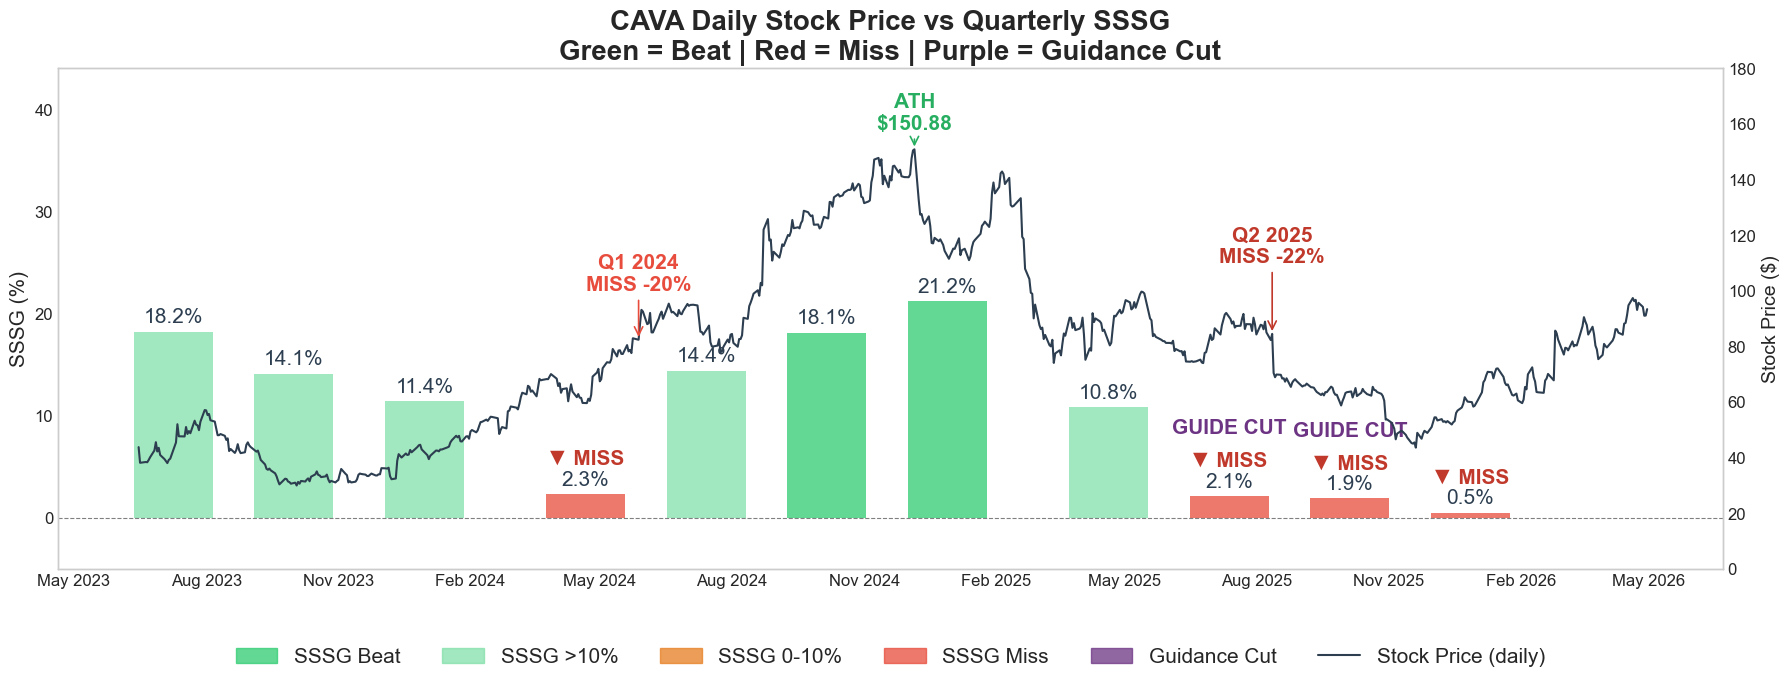

Saved: outputs/figures/stock_price_vs_sssg_daily.png


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np

BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'

# Load data
price_df = pd.read_csv(f'{BASE_DIR}/data/raw/cava_stock_price_raw.csv',
                       parse_dates=['date'])
master = pd.read_csv(f'{BASE_DIR}/data/processed/cava_master_quarterly.csv',
                     parse_dates=['period_end'])

# Filter to post-IPO
price_df = price_df[price_df['date'] >= '2023-06-15'].sort_values('date')
master_plot = master.dropna(subset=['avg_price']).sort_values('period_end').copy()

fig, ax1 = plt.subplots(figsize=(18, 7))
ax2 = ax1.twinx()

# ── Bar chart: quarterly SSSG ──────────────────────────────────────────────────
bar_colors = []
for _, row in master_plot.iterrows():
    if row['sssg_miss'] == 1:
        bar_colors.append('#e74c3c')
    elif row['sssg_beat'] == 1:
        bar_colors.append('#2ecc71')
    elif row['sssg_pct'] > 10:
        bar_colors.append('#82e0aa')
    else:
        bar_colors.append('#e67e22')

bars = ax1.bar(master_plot['period_end'], master_plot['sssg_pct'],
               width=55, color=bar_colors, alpha=0.75,
               label='SSSG %', zorder=2)
ax1.set_ylabel('SSSG (%)', fontsize=15)
ax1.set_ylim(-5, 44)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Line chart: daily stock price ─────────────────────────────────────────────
ax2.plot(price_df['date'], price_df['adj_close_price'],
         color='#2c3e50', linewidth=1.5, label='Stock Price (daily)', zorder=3)
ax2.set_ylabel('Stock Price ($)', fontsize=14)
ax2.set_ylim(0, 180)

key_events = [
    ('2024-12-06', 'ATH\n$150.88', '#27ae60', 158),
    ('2024-05-28', 'Q1 2024\nMISS -20%', '#e74c3c', 100),
    ('2025-08-12', 'Q2 2025\nMISS -22%', '#c0392b', 110),
]

for date_str, label, color, y_pos in key_events:
    date = pd.Timestamp(date_str)
    ax2.annotate(label,
                xy=(date, price_df[price_df['date'] >= date]['adj_close_price'].iloc[0]),
                xytext=(date, y_pos),
                fontsize=15, color=color, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

# ── Annotate SSSG values + MISS + GUIDE CUT on bars ──────────────────────────
for _, row in master_plot.iterrows():
    # SSSG value label
    ax1.text(row['period_end'], row['sssg_pct'] + 0.5,
             f'{row["sssg_pct"]:.1f}%',
             ha='center', va='bottom', fontsize=15, color='#2c3e50')

    # Build annotations list
    annotations = []
    if row['sssg_miss'] == 1:
        annotations.append(('▼ MISS', '#c0392b'))
    if row['guidance_cut'] == 1:
        annotations.append(('GUIDE CUT', '#6c3483'))

    # Stack annotations above the SSSG value label
    for i, (text, color) in enumerate(annotations):
        ax1.text(row['period_end'],
                 row['sssg_pct'] + 2.5 + i * 3.2,
                 text,
                 ha='center', va='bottom', fontsize=15,
                 color=color, fontweight='bold')

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color='#2ecc71', alpha=0.75, label='SSSG Beat'),
    mpatches.Patch(color='#82e0aa', alpha=0.75, label='SSSG >10%'),
    mpatches.Patch(color='#e67e22', alpha=0.75, label='SSSG 0-10%'),
    mpatches.Patch(color='#e74c3c', alpha=0.75, label='SSSG Miss'),
    mpatches.Patch(color='#6c3483', alpha=0.75, label='Guidance Cut'),
    plt.Line2D([0], [0], color='#2c3e50', linewidth=1.5, label='Stock Price (daily)'),
]
ax1.legend(handles=legend_patches,
           loc='upper center', bbox_to_anchor=(0.5, -0.12),
           ncol=6, fontsize=15)

# ── Formatting ─────────────────────────────────────────────────────────────────
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xticks(rotation=45, ha='right')

ax1.set_title('CAVA Daily Stock Price vs Quarterly SSSG\n'
              'Green = Beat | Red = Miss | Purple = Guidance Cut',
              fontweight='bold', fontsize=20)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/stock_price_vs_sssg_daily.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/stock_price_vs_sssg_daily.png')

#### Conclusion:
"Despite clear visual seasonality in CAVA's KPIs, Lasso zeroed out all seasonal encodings (sine/cosine and one-hot quarter dummies). This does not mean seasonality is unimportant — rather, it suggests that seasonality is already implicitly captured by the selected financial features (particularly sssg_pct_lag2 and margin_qoq), making explicit seasonal terms redundant. Adding them introduced multicollinearity that hurt out-of-sample performance."

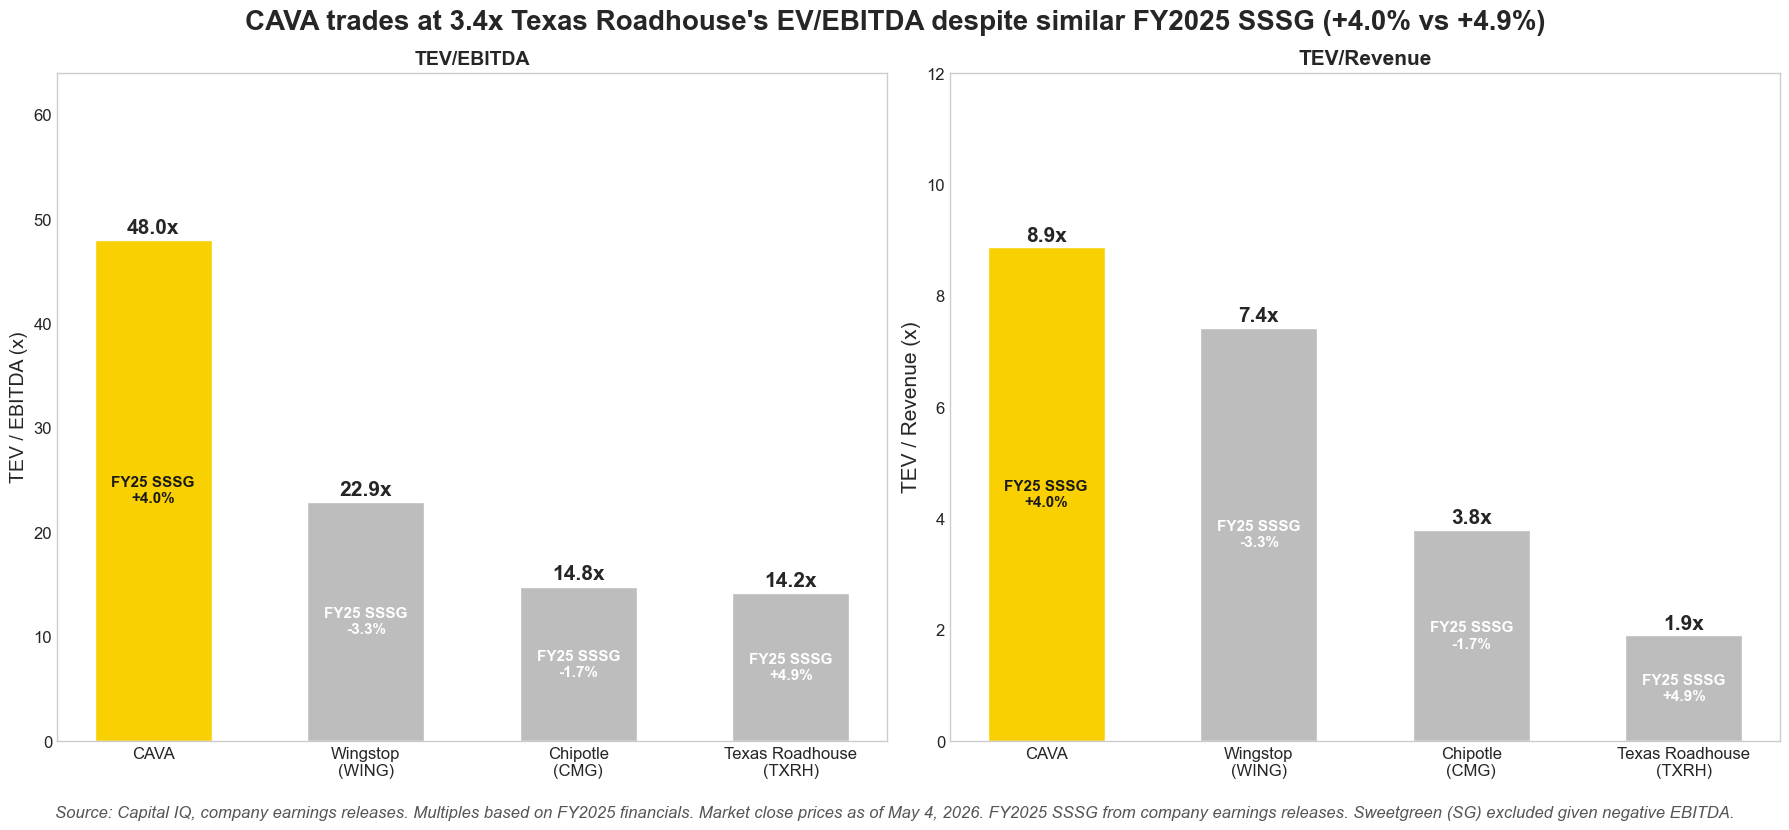

Saved: outputs/figures/valuation_comparison.png


In [87]:
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = '/Users/zhangsu/Cava_Investment_Analysis'

companies = ['CAVA', 'Wingstop\n(WING)', 'Chipotle\n(CMG)', 'Texas Roadhouse\n(TXRH)']
ev_ebitda = [47.99, 22.88, 14.76, 14.15]
ev_revenue = [8.86, 7.42, 3.78, 1.89]
sssg_fy2025 = [+4.0, -3.3, -1.7, +4.9]

CAVA_GOLD = '#F9D002'
PEER_GRAY = '#BDBDBD'
colors = [CAVA_GOLD, PEER_GRAY, PEER_GRAY, PEER_GRAY]
text_colors = ['#1a1a1a', 'white', 'white', 'white']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('CAVA trades at 3.4x Texas Roadhouse\'s EV/EBITDA despite similar FY2025 SSSG (+4.0% vs +4.9%)',
             fontweight='bold', fontsize=20)

# ── EV/EBITDA ──────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(companies, ev_ebitda, color=colors, edgecolor='white', width=0.55)

for bar, val, sssg, tc in zip(bars, ev_ebitda, sssg_fy2025, text_colors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}x', ha='center', va='bottom', fontsize=15, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'FY25 SSSG\n{sssg:+.1f}%', ha='center', va='center',
            fontsize=11, color=tc, fontweight='bold')

ax.set_ylabel('TEV / EBITDA (x)', fontsize=14)
ax.set_title('TEV/EBITDA', fontweight='bold', fontsize=14)
ax.set_ylim(0, 64)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# ── EV/Revenue ─────────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(companies, ev_revenue, color=colors, edgecolor='white', width=0.55)

for bar, val, sssg, tc in zip(bars, ev_revenue, sssg_fy2025, text_colors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}x', ha='center', va='bottom', fontsize=15, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'FY25 SSSG\n{sssg:+.1f}%', ha='center', va='center',
            fontsize=11, color=tc, fontweight='bold')

ax.set_ylabel('TEV / Revenue (x)', fontsize=15)
ax.set_title('TEV/Revenue', fontweight='bold', fontsize=15)
ax.set_ylim(0, 12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Footnote
fig.text(0.5, -0.03,
         'Source: Capital IQ, company earnings releases. Multiples based on FY2025 financials. '
         'Market close prices as of May 4, 2026. '
         'FY2025 SSSG from company earnings releases. '
         'Sweetgreen (SG) excluded given negative EBITDA.',
         ha='center', fontsize=12, color='#555', style='italic')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/figures/valuation_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/valuation_comparison.png')

In [60]:
master['digital_mix_lag1'] = master['digital_revenue_mix_pct'].shift(1)
master['digital_mix_lag2'] = master['digital_revenue_mix_pct'].shift(2)

print('digital_revenue_mix_pct vs sssg_pct_next:',
      master['digital_revenue_mix_pct'].corr(master['sssg_pct_next']))
print('digital_mix_lag1 vs sssg_pct_next:',
      master['digital_mix_lag1'].corr(master['sssg_pct_next']))
print('digital_mix_lag2 vs sssg_pct_next:',
      master['digital_mix_lag2'].corr(master['sssg_pct_next']))

digital_revenue_mix_pct vs sssg_pct_next: -0.48795912700417204
digital_mix_lag1 vs sssg_pct_next: -0.678952584188512
digital_mix_lag2 vs sssg_pct_next: -0.5804921774879499


## Key Findings from Validation Plots

### 1. SSSG Structural Deceleration (Plot 1)
CAVA's same-restaurant sales growth has undergone a clear structural 
deceleration. After peaking at 28.4% in Q1 2023 — driven by post-pandemic 
dining recovery and IPO-related buzz — SSSG has trended sharply lower, 
reaching near-zero levels by Q4 2025 (0.5%). Three consecutive earnings 
misses in 2025 (Q2: 2.1% vs. 6.1% expected; Q3: 1.9% vs. 2.8%; Q4: 0.5%) 
accompanied by two rounds of guidance cuts signal that this is not a 
one-quarter anomaly but a structural shift in demand momentum.

### 2. Stock Price Tracks SSSG Closely (Plot 4)
The alignment between SSSG and stock price is striking. CAVA's stock reached 
an all-time high of ~$150 in Q4 2024, coinciding with its strongest SSSG 
prints of 18.1% and 21.2% in Q3-Q4 2024. As SSSG decelerated through 2025, 
the stock fell from ~$130 to ~$60 — a ~54% decline. This confirms that SSSG 
is the primary valuation driver for CAVA, and any recovery in the stock is 
likely contingent on a re-acceleration in comp sales.

### 3. Google Trends: Weak Leading Indicator (Plot 2)
Google search interest for "CAVA restaurant" spiked around the June 2023 IPO 
but has since plateaued at low absolute levels (0-2 on Google's 0-100 scale). 
The lack of a meaningful trend or correlation with SSSG confirms our earlier 
assessment: CAVA remains a regional brand with limited national search 
penetration, making Google Trends an unreliable predictor of comp sales. 
Notably, Chipotle's search interest remains 50x higher, highlighting CAVA's 
long runway for brand awareness growth — a double-edged signal.

### 4. News Sentiment Co-moves with SSSG (Plot 3)
Over the three quarters where news data is available (Q2-Q4 2025), news 
sentiment and SSSG declined in tandem: sentiment fell from 0.28 to 0.14 
as SSSG dropped from 2.1% to 0.5%. While the sample is too small to draw 
statistical conclusions, the directional alignment suggests news sentiment 
may reflect — rather than predict — fundamental performance. This is 
consistent with VADER's backward-looking nature: headlines react to events 
rather than anticipate them.

### 5. Correlation Heatmap: Key Relationships (Plot 5)
Several notable correlations emerge from the feature matrix:

- **AUV growth vs. SSSG (r = 0.86):** Average unit volume growth is highly 
  correlated with same-store sales, confirming that ticket size and visit 
  frequency improvements drive both metrics simultaneously.
  
- **News sentiment vs. price volatility (r = -0.96):** Strongly negative — 
  periods of negative news coverage coincide with elevated stock price 
  volatility. This is consistent with the August 2025 earnings miss, which 
  generated peak negative coverage and the stock's largest single-day decline.
  
- **Digital revenue mix vs. next-quarter SSSG (r = -0.49):** Counter-intuitive 
  negative correlation. Higher digital mix may reflect consumers shifting to 
  lower-margin digital channels during periods of macro uncertainty, 
  foreshadowing softer foot traffic. Requires further investigation.
  
- **Analyst score vs. SSSG (r = -0.16):** Near-zero correlation confirms that 
  sell-side analyst ratings are lagging indicators — they do not predict SSSG 
  direction, and remained predominantly bullish even as fundamentals 
  deteriorated through 2025.

### 6. Caveat on Small Sample Size
With only 15 quarters of data, all correlations should be interpreted with 
caution. In particular, news sentiment correlations are based on only 3 data 
points and are not statistically meaningful. The modeling notebook addresses 
this limitation through cross-validation and by focusing on the most robust 
features.

---
## Part 6: Save Master Dataset

In [61]:
# ── Save master quarterly dataset ─────────────────────────────────────────────
master = master.drop(columns=['period_start', 'max_search_interest', 'search_interest_std'], errors='ignore')
master.to_csv(f'{BASE_DIR}/data/processed/cava_master_quarterly.csv', index=False)

print('Master dataset saved: data/processed/cava_master_quarterly.csv')
print(f'Shape: {master.shape}')
print(f'Quarters: {master.quarter.tolist()}')
print(f'\nFinal columns:')
for col in master.columns:
    non_null = master[col].notna().sum()
    print(f'  {col:<40} {non_null}/{len(master)} non-null')

Master dataset saved: data/processed/cava_master_quarterly.csv
Shape: (15, 47)
Quarters: ['Q2 2022', 'Q3 2022', 'Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024', 'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025']

Final columns:
  quarter                                  15/15 non-null
  period_end                               15/15 non-null
  revenue_m                                15/15 non-null
  sssg_pct                                 15/15 non-null
  auv_in_thousands                         15/15 non-null
  restaurant_margin_pct                    15/15 non-null
  restaurant_count                         15/15 non-null
  net_new_openings                         15/15 non-null
  digital_revenue_mix_pct                  15/15 non-null
  adj_ebitda_margin_pct                    15/15 non-null
  weeks_in_period                          15/15 non-null
  weekly_revenue_m                         15/15 non-null
  avg_price                      